In [1]:
from pathlib import Path
import os

LOCAL_PROJECT_ROOT = Path('/mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet')
if not LOCAL_PROJECT_ROOT.exists():
    LOCAL_PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path(os.environ.get('AGRISENSE_PROJECT_ROOT', str(LOCAL_PROJECT_ROOT))).expanduser().resolve()
configured_data = os.environ.get('AGRIFIELDNET_DATA_DIR')
DATA_DIR = Path(configured_data).expanduser().resolve() if configured_data else PROJECT_ROOT / 'data'
OUT = PROJECT_ROOT / 'agrifieldnet_final_outputs'
OUT.mkdir(parents=True, exist_ok=True)
RESULTS_ZIP = PROJECT_ROOT / 'agrifieldnet_final_outputs.zip'

# AgriFieldNet India — LOCAL Jupyter GPU-Optimized Sentinel-1/Sentinel-2 Crop Classification Pipeline

**ETET 2026 / AgriSense — complete 8+8 batch workflow**

This version is optimized for local Jupyter/JupyterLab GPU execution. Google Colab upload/download and temporary-runtime path dependencies have been removed.

### Inputs
- 8 files: `agrifieldnet_periodic_features_batch00.csv` … `batch07.csv`
- 8 files: `agrifieldnet_observations_template_batch00.csv` … `batch07.csv`
- optional: `agrifieldnet_train_fields.gpkg` for spatial-block validation

### Primary experiments
- **A0 — Static S2:** seasonal median optical features
- **A1 — Multi-temporal S2:** 21 × 10-day optical sequence
- **A2 — Multi-temporal S1:** ASC/DESC radar sequence retained separately
- **A3 — Multi-temporal S1+S2:** early feature fusion
- **A4 — Temporal descriptors:** distribution, amplitude, trend, peak timing and missingness descriptors


### Local folder layout
Place the notebook in your project folder and put the 16 CSV files in a data folder:

AgriSense/
  AgriFieldNet_GPU_Optimized_Local_Jupyter.ipynb
  data/
    agrifieldnet_periodic_features_batch00.csv ... batch07.csv
    agrifieldnet_observations_template_batch00.csv ... batch07.csv
    agrifieldnet_train_fields.gpkg  (optional, recommended)

You can override the data directory with the AGRIFIELDNET_DATA_DIR environment variable.
Windows users should prefer WSL2 + Ubuntu for modern TensorFlow GPU support.

### GPU / runtime design
- **XGBoost** uses CUDA when an NVIDIA GPU is available.
- **CatBoost** uses GPU training when an NVIDIA GPU is available.
- **CNN1D / GRU / LSTM** use TensorFlow GPU + mixed precision.
- scikit-learn models such as Random Forest, SVM, LDA and Extra Trees remain CPU models and use available CPU threads.
- temporal descriptor construction and sequence-tensor construction are vectorized instead of using slow nested Python loops.
- fold-local preprocessing is computed once per feature-set/fold and reused across all classical models.
- the optical-gap robustness experiment trains each leader only once per fold and reuses it for every masking scenario.
- permutation importance uses bounded repeats/sample size because the original full permutation cell is extremely expensive.

### Run profiles
At the top of the notebook choose:
- `fast` — development/debugging
- `balanced` — **default; recommended for Colab**
- `paper` — heavier final sensitivity run

### Scientific guardrails
- Crop type is the observed AgriFieldNet target.
- AgriFieldNet phenology labels are not invented.
- `field_id` is the independent sample.
- Imputation/scaling remain fold-local.
- If geometry is supplied, spatial grouped validation is used.
- Rare classes remain in evaluation and are reported individually.


In [2]:
# Run once in the same local Python environment used by this Jupyter kernel.
# Skip this cell if these packages are already installed.
%pip install -q -U "xgboost>=2.0" lightgbm catboost geopandas pyogrio

# For CNN/GRU/LSTM GPU execution on Linux or WSL2, install TensorFlow GPU support
# in this environment before running the deep-learning section:
# %pip install -q -U "tensorflow[and-cuda]"

# Native Windows TensorFlow GPU support is limited in current releases; WSL2 is recommended.

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import os, re, json, math, warnings, zipfile, time, subprocess, gc, sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    cohen_kappa_score, matthews_corrcoef,
    top_k_accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CPU_THREADS = max(1, (os.cpu_count() or 2) - 1)
for env_name in ['OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','NUMEXPR_NUM_THREADS']:
    os.environ.setdefault(env_name, str(CPU_THREADS))

def detect_nvidia_gpu():
    try:
        info = subprocess.check_output(
            ['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
            text=True
        ).strip()
        return bool(info), info
    except Exception:
        return False, ''

GPU_AVAILABLE, GPU_INFO = detect_nvidia_gpu()

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Project root:', PROJECT_ROOT)
print('Data directory:', DATA_DIR)
print('Output directory:', OUT)
print('CPU threads:', CPU_THREADS)
print('GPU available:', GPU_AVAILABLE)
if GPU_AVAILABLE:
    print('GPU:', GPU_INFO)
else:
    print(
        '\nWARNING: No NVIDIA GPU detected.\n'
        'On Windows, use WSL2/Linux and confirm that nvidia-smi works in the same environment.\n'
        'The notebook can still run on CPU, but XGBoost,\n'
        'CatBoost and deep models will be slower.'
    )

RUN_PROFILE = 'paper'   # 'fast', 'balanced', or 'paper'

PROFILES = {
    'fast': {'folds': 3, 'rf_trees': 160, 'boost_estimators': 70, 'xgb_estimators': 220, 'cat_iterations': 220, 'lgb_estimators': 220, 'mlp_iter': 140, 'deep_epochs': 22, 'deep_batch': 512, 'deep_patience': 4, 'importance_repeats': 2, 'importance_max_samples': 800, 'robustness_repeats': 4, 'confusion_top_k': 2},
    'balanced': {'folds': 4, 'rf_trees': 260, 'boost_estimators': 110, 'xgb_estimators': 350, 'cat_iterations': 350, 'lgb_estimators': 350, 'mlp_iter': 220, 'deep_epochs': 35, 'deep_batch': 512, 'deep_patience': 6, 'importance_repeats': 3, 'importance_max_samples': 1500, 'robustness_repeats': 8, 'confusion_top_k': 3},
    'paper': {'folds': 4, 'rf_trees': 500, 'boost_estimators': 180, 'xgb_estimators': 600, 'cat_iterations': 600, 'lgb_estimators': 600, 'mlp_iter': 400, 'deep_epochs': 60, 'deep_batch': 256, 'deep_patience': 10, 'importance_repeats': 5, 'importance_max_samples': 2500, 'robustness_repeats': 15, 'confusion_top_k': 999}
}
if RUN_PROFILE not in PROFILES:
    raise ValueError(f'Unknown RUN_PROFILE={RUN_PROFILE}')
P = PROFILES[RUN_PROFILE]

# PROJECT_ROOT, DATA_DIR, OUT and RESULTS_ZIP are initialized in the first cell.
EXPECTED_BATCHES = set(range(8))
EXPECTED_PERIODS = list(range(21))
EXPECTED_FIELDS = 5551
EXPECTED_ROWS = EXPECTED_FIELDS * len(EXPECTED_PERIODS)
REQUESTED_FOLDS = P['folds']
GRID_DEG = 0.10
RUN_DEEP_MODELS = True
RUN_ROBUSTNESS = True
RUN_PERMUTATION_IMPORTANCE = True
SAVE_ALL_CONFUSION_MATRICES = (RUN_PROFILE == 'paper')
DEEP_EPOCHS = P['deep_epochs']
DEEP_BATCH_SIZE = P['deep_batch']
DEEP_PATIENCE = P['deep_patience']

print('\nRun profile:', RUN_PROFILE)
print('Output directory:', OUT)
print('Requested folds:', REQUESTED_FOLDS)


Python: 3.12.3
Platform: Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Project root: /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet
Data directory: /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data
Output directory: /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/agrifieldnet_final_outputs
CPU threads: 11
GPU available: True
GPU: NVIDIA GeForce RTX 2050, 4096 MiB

Run profile: paper
Output directory: /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/agrifieldnet_final_outputs
Requested folds: 4


## 1. Discover all 16 local production CSVs

This local notebook requires:

- agrifieldnet_periodic_features_batch00.csv through batch07.csv
- agrifieldnet_observations_template_batch00.csv through batch07.csv

Place them in DATA_DIR. The default is ./data relative to the directory where Jupyter was started.
If the CSVs are beside the notebook, the notebook automatically uses the project root instead.

Optional for paper-grade spatial validation: agrifieldnet_train_fields.gpkg

In [4]:
def discover_local_files():
    periodic = sorted(DATA_DIR.glob('agrifieldnet_periodic_features_batch*.csv'))
    obs = sorted(DATA_DIR.glob('agrifieldnet_observations_template_batch*.csv'))

    gpkg_candidates = [
        DATA_DIR / 'agrifieldnet_train_fields.gpkg',
        PROJECT_ROOT / 'agrifieldnet_train_fields.gpkg',
    ]
    gpkg = next((p for p in gpkg_candidates if p.exists()), gpkg_candidates[0])
    return periodic, obs, gpkg

periodic_files, obs_files, gpkg_path = discover_local_files()

print('Periodic feature files:', len(periodic_files))
for p in periodic_files: print(' ', p)
print('\nObservation-template files:', len(obs_files))
for p in obs_files: print(' ', p)
print('\nGeometry available:', gpkg_path.exists(), gpkg_path)

if len(periodic_files) != 8 or len(obs_files) != 8:
    expected_periodic = {f'agrifieldnet_periodic_features_batch{i:02d}.csv' for i in range(8)}
    expected_obs = {f'agrifieldnet_observations_template_batch{i:02d}.csv' for i in range(8)}
    actual_periodic = {p.name for p in periodic_files}
    actual_obs = {p.name for p in obs_files}
    missing = sorted((expected_periodic - actual_periodic) | (expected_obs - actual_obs))
    raise FileNotFoundError(
        'The local 8+8 dataset is incomplete.\n'
        f'DATA_DIR = {DATA_DIR}\n'
        'Missing files:\n  - ' + '\n  - '.join(missing)
    )

Periodic feature files: 8
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch00.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch01.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch02.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch03.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch04.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch05.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch06.csv
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_periodic_features_batch07.csv

Observation-template files: 8
  /mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data/agrifieldnet_observations_template_batch00.csv
  /

In [5]:
# ---------- Strict 8+8 batch inventory + concatenate ----------
def batch_number(path):
    m = re.search(r'batch(\d+)', path.name)
    return int(m.group(1)) if m else None

found_batches = {batch_number(p) for p in periodic_files}
found_obs_batches = {batch_number(p) for p in obs_files}

missing_batches = EXPECTED_BATCHES - found_batches
missing_obs_batches = EXPECTED_BATCHES - found_obs_batches
extra_batches = found_batches - EXPECTED_BATCHES
extra_obs_batches = found_obs_batches - EXPECTED_BATCHES

print('Periodic batches:', sorted(found_batches))
print('Observation batches:', sorted(found_obs_batches))
print('Missing periodic:', sorted(missing_batches))
print('Missing observations:', sorted(missing_obs_batches))
print('Unexpected periodic:', sorted(extra_batches))
print('Unexpected observations:', sorted(extra_obs_batches))

assert not missing_batches, f'Missing periodic batches: {sorted(missing_batches)}'
assert not missing_obs_batches, f'Missing observation-template batches: {sorted(missing_obs_batches)}'
assert not extra_batches, f'Unexpected periodic batches: {sorted(extra_batches)}'
assert not extra_obs_batches, f'Unexpected observation batches: {sorted(extra_obs_batches)}'

frames=[]
periodic_schema=None
for p in sorted(periodic_files):
    d=pd.read_csv(p, low_memory=False)
    if periodic_schema is None:
        periodic_schema=list(d.columns)
    else:
        assert list(d.columns)==periodic_schema, f'Periodic schema mismatch: {p.name}'
    d['_source_batch']=batch_number(p)
    frames.append(d)
long=pd.concat(frames,ignore_index=True)

obs_frames=[]
obs_schema=None
for p in sorted(obs_files):
    d=pd.read_csv(p, low_memory=False)
    if obs_schema is None:
        obs_schema=list(d.columns)
    else:
        assert list(d.columns)==obs_schema, f'Observation schema mismatch: {p.name}'
    d['_source_batch']=batch_number(p)
    obs_frames.append(d)
obs=pd.concat(obs_frames,ignore_index=True)

long['field_id']=pd.to_numeric(long['field_id'],errors='raise').astype('Int64')
long['crop_id']=pd.to_numeric(long['crop_id'],errors='raise').astype('Int64')
long['period_index']=pd.to_numeric(long['period_index'],errors='raise').astype('Int64')
for c in ['period_start','period_end','period_mid']:
    long[c]=pd.to_datetime(long[c],errors='raise')

obs['field_id']=pd.to_numeric(obs['field_id'],errors='raise').astype('Int64')
obs['acquisition_date']=pd.to_datetime(obs['acquisition_date'],errors='raise')
obs['sensor']=obs['sensor'].astype(str).str.upper().str.strip()

print('\nPeriodic combined:',long.shape)
print('Observation combined:',obs.shape)
print('Unique periodic fields:',long['field_id'].nunique())
print('Expected full periodic rows:',EXPECTED_ROWS)
print('Actual periodic rows:',len(long))


Periodic batches: [0, 1, 2, 3, 4, 5, 6, 7]
Observation batches: [0, 1, 2, 3, 4, 5, 6, 7]
Missing periodic: []
Missing observations: []
Unexpected periodic: []
Unexpected observations: []

Periodic combined: (116571, 44)
Observation combined: (229009, 8)
Unique periodic fields: 5551
Expected full periodic rows: 116571
Actual periodic rows: 116571


In [6]:
# ---------- Structural / label audit ----------
key_dupes = long.duplicated(['field_id','period_index'], keep=False)
print('Duplicate field-period rows:', int(key_dupes.sum()))
if key_dupes.any():
    display(long.loc[key_dupes, ['field_id','period_index','crop_id','crop_type','_source_batch']].head(20))

per_field = long.groupby('field_id')['period_index'].nunique()
print('\nPeriods per field:')
display(per_field.describe().to_frame('n_periods'))
print('Fields with exactly 21 periods:', int((per_field==21).sum()))

label_conflicts = long.groupby('field_id')['crop_id'].nunique()
print('Fields with conflicting crop_id:', int((label_conflicts>1).sum()))

class_table = (
    long[['field_id','crop_id','crop_type']].drop_duplicates('field_id')
    .groupby(['crop_id','crop_type']).size().rename('fields').reset_index()
    .sort_values('fields', ascending=False)
)
display(class_table)
class_table.to_csv(OUT/'class_support.csv', index=False)

# Missingness audit for core signals.
SIGNAL_COLS_ALL = [
    'B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12',
    'NDVI','NDRE','GNDVI','EVI','LSWI',
    'S1A_VV','S1A_VH','S1A_VVminusVH',
    'S1D_VV','S1D_VH','S1D_VVminusVH'
]
missing = long[SIGNAL_COLS_ALL].isna().mean().sort_values(ascending=False).rename('missing_fraction')
display(missing.to_frame())
missing.to_csv(OUT/'feature_missingness.csv')


# FINAL-run hard checks
assert len(long)==EXPECTED_ROWS, f'Expected {EXPECTED_ROWS} periodic rows, found {len(long)}'
assert long['field_id'].nunique()==EXPECTED_FIELDS, f'Expected {EXPECTED_FIELDS} fields'
assert sorted(long['period_index'].dropna().astype(int).unique().tolist())==EXPECTED_PERIODS, 'period_index must be 0..20'
assert int(key_dupes.sum())==0, 'Duplicate field-period rows detected'
assert (per_field==len(EXPECTED_PERIODS)).all(), 'At least one field does not have 21 periods'
assert int((label_conflicts>1).sum())==0, 'Crop label conflict within a field'
batch_membership=long[['field_id','_source_batch']].drop_duplicates().groupby('field_id')['_source_batch'].nunique()
assert (batch_membership==1).all(), 'A field appears in more than one periodic export batch'
print('\nFINAL PERIODIC INTEGRITY: PASS')


Duplicate field-period rows: 0

Periods per field:


,n_periods
count,5551.0
mean,21.0
std,0.0
min,21.0
25%,21.0
50%,21.0
75%,21.0
max,21.0


Fields with exactly 21 periods: 5551
Fields with conflicting crop_id: 0


,crop_id,crop_type,fields
0,1,Wheat,2031
3,4,No crop/Fallow,1641
1,2,Mustard,990
7,9,Maize,293
5,6,Sugarcane,163
12,36,Rice,129
2,3,Lentil,103
8,13,Gram,59
6,8,Garlic,48
10,15,Potato,41


,missing_fraction
S1A_VV,0.336447
S1A_VVminusVH,0.336447
S1A_VH,0.336447
B3,0.147395
B2,0.147395
B6,0.147395
B5,0.147395
B4,0.147395
B7,0.147395
B12,0.147395



FINAL PERIODIC INTEGRITY: PASS


In [7]:
# ---------- Mandatory observation-template audit ----------
print('Observation-template rows:',len(obs))
print('Observation sensors:')
display(obs['sensor'].value_counts(dropna=False).to_frame('rows'))

assert obs['field_id'].isin(long['field_id'].unique()).all(), 'Observation template contains unknown field IDs'
assert set(obs['_source_batch'].dropna().astype(int).unique())==EXPECTED_BATCHES, 'Observation batches are incomplete'

print('Date range:',obs['acquisition_date'].min(),'to',obs['acquisition_date'].max())
print('Non-null DAS:',int(obs['das'].notna().sum()) if 'das' in obs else 0)
print('Non-null phenology_stage:',int(obs['phenology_stage'].notna().sum()) if 'phenology_stage' in obs else 0)
print('Non-null cloud_free:',int(obs['cloud_free'].notna().sum()) if 'cloud_free' in obs else 0)

# The templates are an audit trail, not the training target table.
expected_s1=int((pd.to_numeric(long['S1_TOTAL_COUNT'],errors='coerce').fillna(0)>0).sum())
expected_s2=int((pd.to_numeric(long['S2_OBS_COUNT'],errors='coerce').fillna(0)>0).sum())
actual_s1=int((obs['sensor']=='S1').sum())
actual_s2=int((obs['sensor']=='S2').sum())

obs_consistency=pd.DataFrame([
    {'sensor':'S1','expected_periodic_presence':expected_s1,'template_rows':actual_s1,'difference':actual_s1-expected_s1},
    {'sensor':'S2','expected_periodic_presence':expected_s2,'template_rows':actual_s2,'difference':actual_s2-expected_s2},
])
display(obs_consistency)
obs_consistency.to_csv(OUT/'observation_template_consistency.csv',index=False)
obs.to_csv(OUT/'observations_template_combined.csv',index=False)

if 'phenology_stage' in obs.columns and obs['phenology_stage'].notna().any():
    print('WARNING: phenology_stage contains non-null values. Inspect them before making any phenology claim.')
else:
    print('Phenology-stage column contains no observed labels; it will NOT be used as a target.')


Observation-template rows: 229009
Observation sensors:


,rows
sensor,
S2,116571
S1,112438


Date range: 2021-11-06 00:00:00 to 2022-05-25 00:00:00
Non-null DAS: 0
Non-null phenology_stage: 0
Non-null cloud_free: 116571


,sensor,expected_periodic_presence,template_rows,difference
0,S1,112438,112438,0
1,S2,116571,116571,0


Phenology-stage column contains no observed labels; it will NOT be used as a target.


## 2. Define scientifically usable predictors

Primary crop models use satellite **signal** features only.

**S2:** reflectance bands + NDVI/NDRE/GNDVI/EVI/LSWI  
**S1:** ASC/DESC VV, VH and VV−VH kept separately

S1 incidence angle, scene counts, clear fraction and Cloud Score+ are retained for QA/robustness analysis but are excluded from the primary crop predictor set to reduce the risk of learning acquisition geometry or location-specific QA patterns.


In [8]:
S2_SIGNAL = [
    'B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12',
    'NDVI','NDRE','GNDVI','EVI','LSWI'
]
S1_SIGNAL = [
    'S1A_VV','S1A_VH','S1A_VVminusVH',
    'S1D_VV','S1D_VH','S1D_VVminusVH'
]
QA_COLS = [
    'S2_OBS_COUNT','S2_CLEAR_COUNT','S2_CLEAR_FRAC','S2_CS_CDF_MED',
    'S1A_COUNT','S1D_COUNT','S1_TOTAL_COUNT'
]

for c in S2_SIGNAL+S1_SIGNAL+QA_COLS:
    long[c]=pd.to_numeric(long[c], errors='coerce')

FIELD_META_COLS = ['field_id','crop_id','crop_type','area_m2','n_fragments','n_source_chips','source_pixels','geometry_type']
field_meta = long[FIELD_META_COLS].drop_duplicates('field_id').set_index('field_id').sort_index()
assert field_meta.index.is_unique
print('Field metadata:', field_meta.shape)


Field metadata: (5551, 7)


In [9]:
# ---------- Build wide 21-period feature matrices ----------
def make_wide(features, prefix=''):
    p = long.pivot_table(index='field_id', columns='period_index', values=features, aggfunc='first')
    # pivot_table produces (feature, period) MultiIndex columns.
    p = p.reindex(columns=pd.MultiIndex.from_product([features, EXPECTED_PERIODS]))
    p.columns = [f'{prefix}{f}__p{int(t):02d}' for f,t in p.columns]
    return p.sort_index()

X_s2_temporal = make_wide(S2_SIGNAL)
X_s1_temporal = make_wide(S1_SIGNAL)
X_fusion_temporal = X_s2_temporal.join(X_s1_temporal, how='outer')

# Static S2 baseline: seasonal median, no temporal ordering.
X_s2_static = long.groupby('field_id')[S2_SIGNAL].median().add_prefix('static_').sort_index()

print('A0 static S2:', X_s2_static.shape)
print('A1 temporal S2:', X_s2_temporal.shape)
print('A2 temporal S1:', X_s1_temporal.shape)
print('A3 temporal fusion:', X_fusion_temporal.shape)


A0 static S2: (5551, 15)
A1 temporal S2: (5551, 315)
A2 temporal S1: (5551, 126)
A3 temporal fusion: (5551, 441)


In [10]:
# ---------- FAST vectorized temporal descriptor matrix ----------
# Original version looped over every field and every feature in Python.
# This version pivots one feature at a time and computes row-wise descriptors in NumPy.

def rowwise_slope(arr):
    arr = np.asarray(arr, dtype=np.float32)
    mask = np.isfinite(arr)
    x = np.arange(arr.shape[1], dtype=np.float32)[None, :]
    n = mask.sum(axis=1).astype(np.float32)

    safe_n = np.where(n > 0, n, 1.0)
    xbar = (mask * x).sum(axis=1) / safe_n
    ysum = np.nansum(arr, axis=1)
    ybar = ysum / safe_n

    dx = x - xbar[:, None]
    dy = arr - ybar[:, None]

    num = np.nansum(np.where(mask, dx * dy, 0.0), axis=1)
    den = np.sum(np.where(mask, dx * dx, 0.0), axis=1)

    out = np.full(arr.shape[0], np.nan, dtype=np.float32)
    ok = (n >= 3) & (den > 0)
    out[ok] = num[ok] / den[ok]
    return out

def descriptor_table_fast(features):
    field_index = pd.Index(sorted(long['field_id'].dropna().unique()), name='field_id')
    out = {}

    for f in features:
        p = (
            long.pivot(index='field_id', columns='period_index', values=f)
                .reindex(index=field_index, columns=EXPECTED_PERIODS)
        )
        a = p.to_numpy(dtype=np.float32)
        finite = np.isfinite(a)
        valid_n = finite.sum(axis=1)

        with np.errstate(all='ignore'):
            out[f'{f}__mean'] = np.nanmean(a, axis=1)
            out[f'{f}__std'] = np.nanstd(a, axis=1)
            out[f'{f}__min'] = np.nanmin(a, axis=1)
            out[f'{f}__max'] = np.nanmax(a, axis=1)
            out[f'{f}__q10'] = np.nanquantile(a, 0.10, axis=1)
            out[f'{f}__q50'] = np.nanquantile(a, 0.50, axis=1)
            out[f'{f}__q90'] = np.nanquantile(a, 0.90, axis=1)

        out[f'{f}__amp'] = out[f'{f}__max'] - out[f'{f}__min']
        out[f'{f}__slope'] = rowwise_slope(a)

        filled = np.where(finite, a, -np.inf)
        peak = np.argmax(filled, axis=1).astype(np.float32)
        peak[valid_n == 0] = np.nan
        out[f'{f}__peak_period'] = peak
        out[f'{f}__valid_fraction'] = finite.mean(axis=1).astype(np.float32)

    return pd.DataFrame(out, index=field_index)

t0 = time.time()
X_descriptors = descriptor_table_fast(S2_SIGNAL + S1_SIGNAL)
print('A4 temporal descriptors:', X_descriptors.shape)
print('Descriptor build time:', round(time.time()-t0, 2), 's')


A4 temporal descriptors: (5551, 231)
Descriptor build time: 17.0 s


In [11]:
# ---------- Targets + common field index ----------
all_fields = field_meta.index
FEATURE_SETS = {
    'A0_S2_static': X_s2_static.reindex(all_fields),
    'A1_S2_temporal': X_s2_temporal.reindex(all_fields),
    'A2_S1_temporal': X_s1_temporal.reindex(all_fields),
    'A3_S1_S2_temporal': X_fusion_temporal.reindex(all_fields),
    'A4_temporal_descriptors': X_descriptors.reindex(all_fields),
}

y_text = field_meta.loc[all_fields,'crop_type'].astype(str)
le = LabelEncoder()
y = le.fit_transform(y_text)
CLASS_NAMES = list(le.classes_)
CLASS_IDS = np.arange(len(CLASS_NAMES))

print('Classes:', CLASS_NAMES)
print('Samples:', len(y))


Classes: ['Bersem', 'Coriander', 'Garlic', 'Gram', 'Green pea', 'Lentil', 'Maize', 'Mustard', 'No crop/Fallow', 'Potato', 'Rice', 'Sugarcane', 'Wheat']
Samples: 5551


## 3. Validation design

If `agrifieldnet_train_fields.gpkg` is present, fields are assigned to 0.10° spatial grid cells and `StratifiedGroupKFold` keeps each spatial cell wholly within one fold. This is the **paper-grade** mode.

If geometry is absent, the notebook uses `StratifiedKFold` as an internal benchmark only. The output explicitly records which mode was used.


In [12]:
# ---------- Spatial blocks when geometry is available ----------
VALIDATION_MODE = 'stratified_internal'
spatial_groups = None

if gpkg_path.exists():
    import geopandas as gpd
    gdf = gpd.read_file(gpkg_path)
    gdf['field_id'] = pd.to_numeric(gdf['field_id'], errors='coerce').astype('Int64')
    gdf = gdf.dropna(subset=['field_id']).drop_duplicates('field_id').set_index('field_id')
    if gdf.crs is None:
        raise ValueError('Geometry file has no CRS. Set its CRS before spatial validation.')
    g4326 = gdf.to_crs(4326)
    rp = g4326.geometry.representative_point()
    coords = pd.DataFrame({'lon':rp.x,'lat':rp.y}, index=g4326.index)
    coords = coords.reindex(all_fields)
    gx = np.floor(coords['lon']/GRID_DEG).astype('Int64')
    gy = np.floor(coords['lat']/GRID_DEG).astype('Int64')
    spatial_groups = gx.astype(str)+'_'+gy.astype(str)
    VALIDATION_MODE = 'spatial_grid_stratified_group'
    print('Spatial groups:', spatial_groups.nunique())
else:
    print('WARNING: geometry not supplied -> using stratified field CV for INTERNAL benchmarking.')
    print('Upload agrifieldnet_train_fields.gpkg before final paper results.')

print('Validation mode:', VALIDATION_MODE)


Spatial groups: 251
Validation mode: spatial_grid_stratified_group


In [13]:
# ---------- Build folds, automatically reducing k if spatial support is too sparse ----------
def build_folds(y, groups=None, requested=4):
    Xdummy=np.zeros((len(y),1))
    candidates=list(range(requested,1,-1))
    for k in candidates:
        try:
            if groups is None:
                splitter=StratifiedKFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)
                folds=list(splitter.split(Xdummy,y))
            else:
                splitter=StratifiedGroupKFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)
                folds=list(splitter.split(Xdummy,y,groups))
            # Every TRAIN fold must contain every class.
            ok=all(set(np.unique(y[tr]))==set(CLASS_IDS) for tr,te in folds)
            if ok:
                return folds,k
        except Exception:
            pass
    raise RuntimeError('Could not construct >=2 folds with every class represented in training. Review spatial groups / rare classes.')

folds, N_FOLDS = build_folds(y, spatial_groups, REQUESTED_FOLDS)
print('Using folds:', N_FOLDS)

fold_audit=[]
for i,(tr,te) in enumerate(folds):
    for split,name in [(tr,'train'),(te,'test')]:
        vc=pd.Series(le.inverse_transform(y[split])).value_counts()
        for cls in CLASS_NAMES:
            fold_audit.append({'fold':i,'split':name,'class':cls,'support':int(vc.get(cls,0))})
fold_audit=pd.DataFrame(fold_audit)
display(fold_audit.pivot_table(index=['fold','split'],columns='class',values='support',fill_value=0))
fold_audit.to_csv(OUT/'fold_class_support.csv',index=False)


Using folds: 4


class       Bersem  Coriander  Garlic  Gram  Green pea  Lentil  Maize  \
fold split                                                              
0    test      4.0        3.0    12.0  14.0        6.0    25.0   74.0   
     train    12.0       11.0    36.0  45.0       17.0    78.0  219.0   
1    test      4.0        3.0    12.0  15.0        6.0    25.0   72.0   
     train    12.0       11.0    36.0  44.0       17.0    78.0  221.0   
2    test      4.0        4.0    12.0  15.0        5.0    26.0   72.0   
     train    12.0       10.0    36.0  44.0       18.0    77.0  221.0   
3    test      4.0        4.0    12.0  15.0        6.0    27.0   75.0   
     train    12.0       10.0    36.0  44.0       17.0    76.0  218.0   

class       Mustard  No crop/Fallow  Potato  Rice  Sugarcane   Wheat  
fold split                                                            
0    test     247.0           409.0    11.0  32.0       41.0   508.0  
     train    743.0          1232.0    30.0  97.0      122.0  1523.0  
1    test     247.0           409.0     9.0  33.0       41.0   508.0  
     train    743.0          1232.0    32.0  96.0      122.0  1523.0  
2    test     248.0           414.0    11.0  32.0       40.0   508.0  
     train    742.0          1227.0    30.0  97.0      123.0  1523.0  
3    test     248.0           409.0    10.0  32.0       41.0   507.0  
     train    742.0          1232.0    31.0  97.0      122.0  1524.0

## 4. Classical / tabular model benchmark

The suite spans linear, distance-based, probabilistic, tree-ensemble, boosting and shallow-neural baselines. Models are compared on identical folds. The primary metric is **Macro-F1**, followed by balanced accuracy, weighted-F1, Cohen's κ and MCC.


In [14]:
# ---------- GPU-aware model registry ----------
def make_models():
    models = {
        'DummyMostFrequent': DummyClassifier(strategy='most_frequent'),

        'LogisticRegression': LogisticRegression(
            max_iter=2500, class_weight='balanced',
            C=1.0, random_state=RANDOM_STATE
        ),

        'LinearSVM': LinearSVC(
            C=1.0, class_weight='balanced',
            dual='auto', random_state=RANDOM_STATE
        ),

        'RBF_SVM': SVC(
            C=3.0, gamma='scale', class_weight='balanced',
            probability=False, cache_size=6000,
            random_state=RANDOM_STATE
        ),

        'KNN': KNeighborsClassifier(
            n_neighbors=9, weights='distance',
            n_jobs=CPU_THREADS
        ),

        'GaussianNB': GaussianNB(),

        'ShrinkageLDA': LinearDiscriminantAnalysis(
            solver='lsqr', shrinkage='auto'
        ),

        'DecisionTree': DecisionTreeClassifier(
            class_weight='balanced', min_samples_leaf=2,
            random_state=RANDOM_STATE
        ),

        'RandomForest': RandomForestClassifier(
            n_estimators=P['rf_trees'],
            max_features='sqrt',
            class_weight='balanced_subsample',
            n_jobs=CPU_THREADS,
            random_state=RANDOM_STATE
        ),

        'ExtraTrees': ExtraTreesClassifier(
            n_estimators=P['rf_trees'],
            max_features='sqrt',
            class_weight='balanced',
            n_jobs=CPU_THREADS,
            random_state=RANDOM_STATE
        ),

        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=P['boost_estimators'],
            learning_rate=0.05,
            max_depth=2,
            random_state=RANDOM_STATE
        ),

        'HistGradientBoosting': HistGradientBoostingClassifier(
            max_iter=P['boost_estimators'] * 2,
            learning_rate=0.06,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),

        'MLP': MLPClassifier(
            hidden_layer_sizes=(192,96),
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=P['mlp_iter'],
            early_stopping=True,
            validation_fraction=0.12,
            n_iter_no_change=12,
            random_state=RANDOM_STATE
        ),
    }

    try:
        from xgboost import XGBClassifier
        xgb_args = dict(
            n_estimators=P['xgb_estimators'],
            max_depth=6,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.80,
            objective='multi:softprob',
            eval_metric='mlogloss',
            tree_method='hist',
            max_bin=256,
            n_jobs=CPU_THREADS,
            random_state=RANDOM_STATE
        )
        if GPU_AVAILABLE:
            xgb_args['device'] = 'cuda'
        models['XGBoost'] = XGBClassifier(**xgb_args)
        print('XGBoost device:', 'cuda' if GPU_AVAILABLE else 'cpu')
    except Exception as e:
        print('XGBoost unavailable:', e)

    try:
        from lightgbm import LGBMClassifier
        # Standard Colab LightGBM wheel is kept on CPU for reliability.
        models['LightGBM'] = LGBMClassifier(
            n_estimators=P['lgb_estimators'],
            learning_rate=0.04,
            num_leaves=31,
            class_weight='balanced',
            verbosity=-1,
            n_jobs=CPU_THREADS,
            random_state=RANDOM_STATE
        )
    except Exception as e:
        print('LightGBM unavailable:', e)

    try:
        from catboost import CatBoostClassifier
        cat_args = dict(
            iterations=P['cat_iterations'],
            depth=7,
            learning_rate=0.04,
            loss_function='MultiClass',
            auto_class_weights='Balanced',
            verbose=False,
            allow_writing_files=False,
            random_seed=RANDOM_STATE,
            thread_count=CPU_THREADS
        )
        if GPU_AVAILABLE:
            cat_args.update(task_type='GPU', devices='0')
        models['CatBoost'] = CatBoostClassifier(**cat_args)
        print('CatBoost device:', 'GPU' if GPU_AVAILABLE else 'CPU')
    except Exception as e:
        print('CatBoost unavailable:', e)

    return models

MODELS = make_models()
print('Models:', list(MODELS))


XGBoost device: cuda
CatBoost device: GPU
Models: ['DummyMostFrequent', 'LogisticRegression', 'LinearSVM', 'RBF_SVM', 'KNN', 'GaussianNB', 'ShrinkageLDA', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'HistGradientBoosting', 'MLP', 'XGBoost', 'LightGBM', 'CatBoost']


In [15]:
# ---------- Fold-local preprocessing + metrics ----------
# Fit preprocessing ONCE per feature-set/fold and reuse it across all models.

def fit_preprocessor(X_train):
    imputer = SimpleImputer(
        strategy='median',
        add_indicator=True,
        keep_empty_features=True
    )
    Xtr = imputer.fit_transform(X_train).astype(np.float32, copy=False)

    scaler = StandardScaler(copy=False)
    Xtr = scaler.fit_transform(Xtr).astype(np.float32, copy=False)

    return imputer, scaler, Xtr

def transform_preprocessor(imputer, scaler, X):
    Z = imputer.transform(X).astype(np.float32, copy=False)
    Z = scaler.transform(Z).astype(np.float32, copy=False)
    return Z

# Retained for permutation importance, where original-column permutation is desirable.
def make_pipeline(estimator):
    return Pipeline([
        ('imputer', SimpleImputer(
            strategy='median',
            add_indicator=True,
            keep_empty_features=True
        )),
        ('scaler', StandardScaler()),
        ('model', estimator)
    ])

def metrics(y_true,y_pred):
    return {
        'accuracy':accuracy_score(y_true,y_pred),
        'balanced_accuracy':balanced_accuracy_score(y_true,y_pred),
        'macro_precision':precision_score(y_true,y_pred,average='macro',labels=CLASS_IDS,zero_division=0),
        'macro_recall':recall_score(y_true,y_pred,average='macro',labels=CLASS_IDS,zero_division=0),
        'macro_f1':f1_score(y_true,y_pred,average='macro',labels=CLASS_IDS,zero_division=0),
        'weighted_f1':f1_score(y_true,y_pred,average='weighted',labels=CLASS_IDS,zero_division=0),
        'kappa':cohen_kappa_score(y_true,y_pred),
        'mcc':matthews_corrcoef(y_true,y_pred),
    }


In [16]:
# # ---------- FAST classical benchmark ----------
# # Key optimization: preprocessing is computed once per fold and reused by every model.

# result_rows=[]
# pred_rows=[]

# for fs_name, Xdf in FEATURE_SETS.items():
#     Xdf = Xdf.astype(np.float32)
#     print('\n###', fs_name, Xdf.shape)

#     prep_cache = []
#     prep_t0 = time.time()

#     for fold,(tr,te) in enumerate(folds):
#         imputer, scaler, Xtr = fit_preprocessor(Xdf.iloc[tr])
#         Xte = transform_preprocessor(imputer, scaler, Xdf.iloc[te])

#         prep_cache.append({
#             'fold': fold,
#             'tr': tr,
#             'te': te,
#             'Xtr': Xtr,
#             'Xte': Xte,
#             'imputer': imputer,
#             'scaler': scaler,
#         })

#     print('Preprocessing cache built in', round(time.time()-prep_t0,2), 's')

#     for model_name, est in MODELS.items():
#         fold_true=[]
#         fold_pred=[]
#         t0=time.time()
#         failed=False

#         for C in prep_cache:
#             fold=C['fold']
#             tr=C['tr']
#             te=C['te']

#             model=clone(est)

#             try:
#                 model.fit(C['Xtr'], y[tr])
#                 pr=model.predict(C['Xte'])
#             except Exception as e:
#                 print('SKIP',fs_name,model_name,'fold',fold,'->',str(e)[:180])
#                 failed=True
#                 break

#             mr=metrics(y[te],pr)
#             result_rows.append({
#                 'feature_set':fs_name,
#                 'model':model_name,
#                 'fold':fold,
#                 'validation_mode':VALIDATION_MODE,
#                 **mr
#             })

#             fold_true.extend(y[te].tolist())
#             fold_pred.extend(pr.tolist())

#             for pos,yt,yp in zip(te,y[te],pr):
#                 pred_rows.append({
#                     'field_id':int(all_fields[pos]),
#                     'feature_set':fs_name,
#                     'model':model_name,
#                     'fold':fold,
#                     'y_true':le.inverse_transform([yt])[0],
#                     'y_pred':le.inverse_transform([yp])[0]
#                 })

#             del model
#             gc.collect()

#         if (not failed) and fold_true:
#             result_rows.append({
#                 'feature_set':fs_name,
#                 'model':model_name,
#                 'fold':'OOF',
#                 'validation_mode':VALIDATION_MODE,
#                 **metrics(np.array(fold_true),np.array(fold_pred))
#             })

#             print(
#                 model_name,
#                 'macro-F1=',round(
#                     f1_score(
#                         fold_true,fold_pred,
#                         average='macro',
#                         labels=CLASS_IDS,
#                         zero_division=0
#                     ),4
#                 ),
#                 'time=',round(time.time()-t0,1),'s'
#             )

#     # Checkpoint after each feature set so a Colab disconnect does not lose everything.
#     pd.DataFrame(result_rows).to_csv(OUT/'checkpoint_model_metrics.csv',index=False)
#     pd.DataFrame(pred_rows).to_csv(OUT/'checkpoint_model_predictions.csv',index=False)

#     del prep_cache
#     gc.collect()

# results=pd.DataFrame(result_rows)
# predictions=pd.DataFrame(pred_rows)

# leaderboard=(
#     results[results['fold'].astype(str)=='OOF']
#     .sort_values(['feature_set','macro_f1'],ascending=[True,False])
#     .reset_index(drop=True)
# )

# display(leaderboard)

# results.to_csv(OUT/'model_metrics_all_folds.csv',index=False)
# leaderboard.to_csv(OUT/'model_leaderboard_oof.csv',index=False)
# predictions.to_csv(OUT/'model_oof_predictions.csv',index=False)


In [17]:
# ============================================================
# RECOVER COMPLETED PAPER-MODE RESULTS AFTER KERNEL RESTART
# ============================================================

results = pd.read_csv(
    OUT / "model_metrics_all_folds.csv"
)

leaderboard = pd.read_csv(
    OUT / "model_leaderboard_oof.csv"
)

predictions = pd.read_csv(
    OUT / "model_oof_predictions.csv"
)

leaders = pd.read_csv(
    OUT / "sensor_ablation_leaders.csv"
)

print("Recovered completed classical experiment.")
print("Results:", results.shape)
print("Predictions:", predictions.shape)
print("Leaderboard:", leaderboard.shape)

display(
    leaderboard
    .sort_values(["feature_set", "macro_f1"],
                 ascending=[True, False])
)

Recovered completed classical experiment.
Results: (400, 12)
Predictions: (444080, 6)
Leaderboard: (80, 12)


,feature_set,model,fold,validation_mode,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,kappa,mcc
0,A0_S2_static,CatBoost,OOF,spatial_grid_stratified_group,0.577373,0.288200,0.249092,0.288200,0.259797,0.588694,0.446413,0.448168
1,A0_S2_static,LinearSVM,OOF,spatial_grid_stratified_group,0.540803,0.303430,0.248672,0.303430,0.246591,0.568318,0.414858,0.420491
2,A0_S2_static,HistGradientBoosting,OOF,spatial_grid_stratified_group,0.609440,0.235394,0.261509,0.235394,0.238833,0.591128,0.460302,0.461486
3,A0_S2_static,LightGBM,OOF,spatial_grid_stratified_group,0.619348,0.227620,0.295852,0.227620,0.235431,0.594675,0.468077,0.470406
4,A0_S2_static,RBF_SVM,OOF,spatial_grid_stratified_group,0.401910,0.345261,0.264239,0.345261,0.235129,0.477428,0.306556,0.324975
...,...,...,...,...,...,...,...,...,...,...,...,...
75,A4_temporal_descriptors,GradientBoosting,OOF,spatial_grid_stratified_group,0.695911,0.306052,0.366702,0.306052,0.321476,0.676699,0.578151,0.580844
76,A4_temporal_descriptors,RandomForest,OOF,spatial_grid_stratified_group,0.708341,0.305368,0.395640,0.305368,0.320107,0.681565,0.591599,0.597016
77,A4_temporal_descriptors,DecisionTree,OOF,spatial_grid_stratified_group,0.568907,0.299951,0.276508,0.299951,0.285464,0.582060,0.432719,0.433685
78,A4_temporal_descriptors,GaussianNB,OOF,spatial_grid_stratified_group,0.199604,0.258310,0.300886,0.258310,0.144285,0.245211,0.150484,0.177728


In [18]:
# ---------- Fold mean ± SD table ----------
fold_numeric=results[results['fold'].astype(str)!='OOF'].copy()
metric_cols=['macro_f1','balanced_accuracy','accuracy','weighted_f1','kappa','mcc']
summary=(fold_numeric.groupby(['feature_set','model'])[metric_cols].agg(['mean','std']).reset_index())
display(summary)
summary.to_csv(OUT/'model_fold_mean_std.csv',index=False)


feature_set              model  macro_f1            \
                                                    mean       std   
0              A0_S2_static           CatBoost  0.259163  0.013036   
1              A0_S2_static       DecisionTree  0.197787  0.006793   
2              A0_S2_static  DummyMostFrequent  0.041211  0.000089   
3              A0_S2_static         ExtraTrees  0.220041  0.001888   
4              A0_S2_static         GaussianNB  0.172618  0.007286   
..                      ...                ...       ...       ...   
75  A4_temporal_descriptors                MLP  0.344403  0.019766   
76  A4_temporal_descriptors            RBF_SVM  0.357228  0.020663   
77  A4_temporal_descriptors       RandomForest  0.319145  0.018044   
78  A4_temporal_descriptors       ShrinkageLDA  0.363450  0.018204   
79  A4_temporal_descriptors            XGBoost  0.339980  0.032158   

   balanced_accuracy            accuracy           weighted_f1            \
                mean       std      mean       std        mean       std   
0           0.288138  0.016235  0.577398  0.019602    0.588286  0.022917   
1           0.207710  0.010100  0.461354  0.002890    0.478727  0.008106   
2           0.076923  0.000000  0.365882  0.001084    0.196020  0.001006   
3           0.217869  0.005885  0.634139  0.025081    0.591915  0.023211   
4           0.275850  0.011258  0.334753  0.021882    0.375487  0.019441   
..               ...       ...       ...       ...         ...       ...   
75          0.332630  0.025114  0.715916  0.022112    0.696459  0.021532   
76          0.410427  0.025441  0.651597  0.013413    0.676613  0.013269   
77          0.305321  0.019341  0.708335  0.024797    0.681117  0.023944   
78          0.395743  0.010447  0.700235  0.015039    0.700371  0.013223   
79          0.323895  0.028775  0.724547  0.026096    0.700580  0.026393   

       kappa                 mcc            
        mean       std      mean       std  
0   0.446320  0.028588  0.448619  0.028737  
1   0.298976  0.009708  0.300779  0.010535  
2   0.000000  0.000000  0.000000  0.000000  
3   0.476606  0.036732  0.487188  0.035846  
4   0.220348  0.014200  0.235818  0.013305  
..       ...       ...       ...       ...  
75  0.608965  0.030986  0.610722  0.030114  
76  0.552803  0.017582  0.558420  0.016912  
77  0.591527  0.035613  0.597363  0.033913  
78  0.598727  0.018801  0.600931  0.017542  
79  0.617271  0.036629  0.619991  0.035872  

[80 rows x 14 columns]

In [19]:
# # ---------- Model-comparison plots ----------
# for fs in FEATURE_SETS:
#     d=leaderboard[leaderboard['feature_set']==fs].sort_values('macro_f1')
#     if d.empty: continue
#     fig,ax=plt.subplots(figsize=(10,6))
#     ax.barh(d['model'],d['macro_f1'])
#     ax.set_xlim(0,1); ax.set_xlabel('Out-of-fold Macro-F1'); ax.set_title(f'{fs}: model comparison')
#     ax.grid(axis='x',alpha=0.2)
#     plt.tight_layout(); plt.savefig(OUT/f'01_model_comparison_{fs}.png',dpi=180); plt.show()


In [20]:
# # ---------- Per-class reports for ALL models; confusion plots for selected models ----------
# # Plotting 100+ large figures can take several minutes and adds little scientific value.
# # Balanced/Fast profiles save plots for the top K models in each feature set.
# # Paper profile saves plots for all successful models.

# cm_dir=OUT/'confusion_matrices'
# report_dir=OUT/'classification_reports'
# cm_dir.mkdir(exist_ok=True)
# report_dir.mkdir(exist_ok=True)

# n_cm = 0
# n_reports = 0

# for fs in FEATURE_SETS:
#     ranked=leaderboard[leaderboard['feature_set']==fs].sort_values('macro_f1',ascending=False)
#     if ranked.empty:
#         continue

#     plot_models = (
#         set(ranked['model'])
#         if SAVE_ALL_CONFUSION_MATRICES
#         else set(ranked.head(P['confusion_top_k'])['model'])
#     )

#     for _,rr in ranked.iterrows():
#         model_name=rr['model']
#         p=predictions[
#             (predictions['feature_set']==fs) &
#             (predictions['model']==model_name)
#         ]
#         if p.empty:
#             continue

#         report=pd.DataFrame(
#             classification_report(
#                 p['y_true'],p['y_pred'],
#                 labels=CLASS_NAMES,
#                 output_dict=True,
#                 zero_division=0
#             )
#         ).T
#         report.to_csv(report_dir/f'report__{fs}__{model_name}.csv')
#         n_reports += 1

#         if model_name not in plot_models:
#             continue

#         fig,ax=plt.subplots(figsize=(10,9))
#         ConfusionMatrixDisplay.from_predictions(
#             p['y_true'],p['y_pred'],
#             labels=CLASS_NAMES,
#             display_labels=CLASS_NAMES,
#             xticks_rotation=60,
#             cmap='Blues',
#             colorbar=False,
#             ax=ax
#         )
#         ax.set_title(f'{fs} — {model_name}\nOOF confusion matrix')
#         plt.tight_layout()
#         plt.savefig(cm_dir/f'CM_counts__{fs}__{model_name}.png',dpi=160)
#         plt.close(fig)

#         fig,ax=plt.subplots(figsize=(10,9))
#         ConfusionMatrixDisplay.from_predictions(
#             p['y_true'],p['y_pred'],
#             labels=CLASS_NAMES,
#             display_labels=CLASS_NAMES,
#             normalize='true',
#             values_format='.2f',
#             xticks_rotation=60,
#             cmap='Blues',
#             colorbar=False,
#             ax=ax
#         )
#         ax.set_title(f'{fs} — {model_name}\nRow-normalized OOF confusion matrix')
#         plt.tight_layout()
#         plt.savefig(cm_dir/f'CM_normalized__{fs}__{model_name}.png',dpi=160)
#         plt.close(fig)
#         n_cm += 2

# print('Classification reports saved for all successful models:', n_reports)
# print('Confusion-matrix PNG files saved:', n_cm)
# print('SAVE_ALL_CONFUSION_MATRICES =', SAVE_ALL_CONFUSION_MATRICES)


## 5. Sensor ablation summary

This directly answers whether temporal S1 contributes beyond S2. Compare A1, A2 and A3 on identical folds. A0 tests whether time-series information itself improves over a static seasonal optical summary.


In [21]:
# # ---------- Feature-set leaders / ablation table ----------
# leaders=(leaderboard.sort_values('macro_f1',ascending=False).groupby('feature_set',as_index=False).first())
# leaders=leaders[['feature_set','model','macro_f1','balanced_accuracy','accuracy','weighted_f1','kappa','mcc','validation_mode']]
# display(leaders)
# leaders.to_csv(OUT/'sensor_ablation_leaders.csv',index=False)

# fig,ax=plt.subplots(figsize=(10,5))
# d=leaders.sort_values('macro_f1')
# ax.barh(d['feature_set'],d['macro_f1'])
# ax.set_xlim(0,1); ax.set_xlabel('OOF Macro-F1'); ax.set_title('Sensor / temporal ablation')
# ax.grid(axis='x',alpha=0.2)
# plt.tight_layout(); plt.savefig(OUT/'04_sensor_ablation.png',dpi=180); plt.show()


Permutation importance leader: HistGradientBoosting | repeats: 2 | max_samples: 400 | quick exploratory estimate: True
Fold 1/4: fitting HistGradientBoosting...
  Fit finished in 316.3s; starting 882 permutation scores...
 fold 0 time= 403.1 s
Fold 2/4: fitting HistGradientBoosting...
  Fit finished in 348.2s; starting 882 permutation scores...
 fold 1 time= 441.7 s
Fold 3/4: fitting HistGradientBoosting...
  Fit finished in 381.8s; starting 882 permutation scores...
 fold 2 time= 480.2 s
Fold 4/4: fitting HistGradientBoosting...
  Fit finished in 358.1s; starting 882 permutation scores...
 fold 3 time= 456.9 s


,importance_mean
feature,
B2__p07,0.025728
S1D_VV__p08,0.012785
GNDVI__p00,0.011298
S1A_VVminusVH__p11,0.010727
S1A_VVminusVH__p07,0.010422
NDRE__p09,0.009883
S1A_VV__p06,0.009579
B2__p09,0.005922
S1A_VV__p13,0.005818


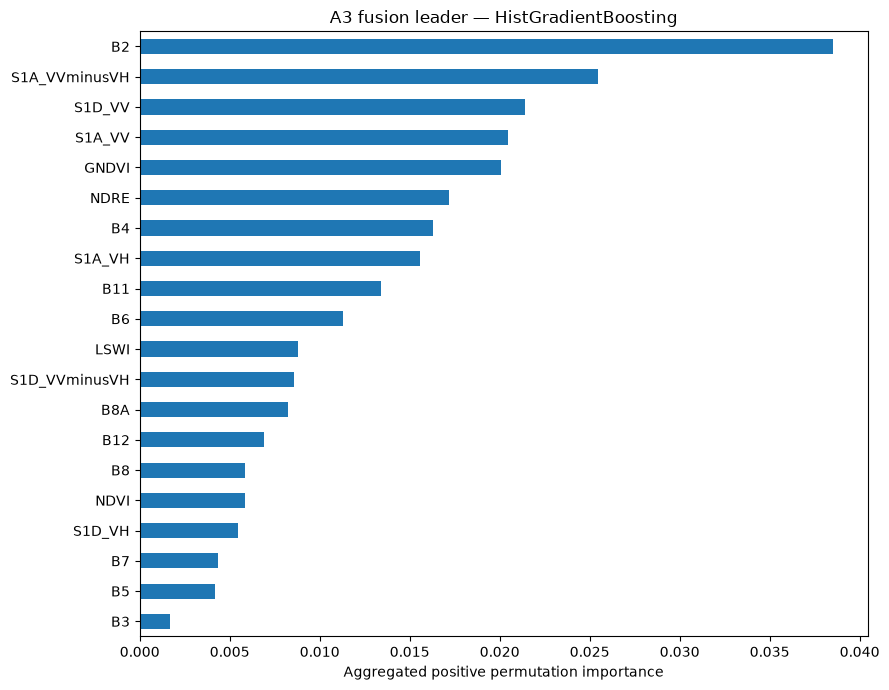

In [22]:
# ---------- Bounded permutation importance for the A3 fusion leader ----------
# Full permutation of 400+ features × many repeats is one of the slowest cells.
# This version keeps the evaluation fold-local but bounds repetitions/sample count.

# Fast exploratory estimates; use False for the original paper sampling budget.
# All original features and validation folds are retained.
from threadpoolctl import threadpool_limits
IMPORTANCE_QUICK = True
importance_repeats = min(2, P['importance_repeats']) if IMPORTANCE_QUICK else P['importance_repeats']
importance_samples = min(400, P['importance_max_samples']) if IMPORTANCE_QUICK else P['importance_max_samples']
importance_threads = min(4, CPU_THREADS)

rank=leaderboard[leaderboard['feature_set']=='A3_S1_S2_temporal']

if RUN_PERMUTATION_IMPORTANCE and not rank.empty:
    leader_name=rank.iloc[0]['model']
    Xdf=FEATURE_SETS['A3_S1_S2_temporal'].astype(np.float32)
    imp_rows=[]

    print(
        'Permutation importance leader:', leader_name,
        '| repeats:', importance_repeats,
        '| max_samples:', importance_samples,
        '| quick exploratory estimate:', IMPORTANCE_QUICK,
        flush=True
    )

    for fold,(tr,te) in enumerate(folds):
        t0=time.time()
        model=make_pipeline(clone(MODELS[leader_name]))
        print(f'Fold {fold + 1}/{len(folds)}: fitting {leader_name}...', flush=True)
        with threadpool_limits(limits=importance_threads):
            model.fit(Xdf.iloc[tr],y[tr])
        print(f'  Fit finished in {time.time()-t0:.1f}s; starting '
              f'{Xdf.shape[1] * importance_repeats} permutation scores...', flush=True)

        # Avoid process copies and nested model/OpenMP parallelism on Windows.
        pi_jobs = 1

        max_samples = min(importance_samples, len(te))

        rng = np.random.RandomState(RANDOM_STATE + fold)
        eval_idx = rng.choice(te, size=max_samples, replace=False)
        X_eval, y_eval = Xdf.iloc[eval_idx], y[eval_idx]
        with threadpool_limits(limits=importance_threads):
            pi=permutation_importance(
                model,
                X_eval,
                y_eval,
                scoring='f1_macro',
                n_repeats=importance_repeats,
                random_state=RANDOM_STATE + fold,
                n_jobs=pi_jobs,
                max_samples=1.0
            )

        for f,mn,sd in zip(Xdf.columns,pi.importances_mean,pi.importances_std):
            imp_rows.append({
                'fold':fold,
                'feature':f,
                'importance_mean':mn,
                'importance_std':sd
            })

        print(' fold',fold,'time=',round(time.time()-t0,1),'s', flush=True)
        del model, pi
        gc.collect()

    imp=pd.DataFrame(imp_rows)
    imp_avg=(
        imp.groupby('feature')['importance_mean']
        .mean()
        .sort_values(ascending=False)
    )

    display(imp_avg.head(30).to_frame())
    importance_suffix = '_quick' if IMPORTANCE_QUICK else ''
    imp.to_csv(OUT/f'fusion_permutation_importance{importance_suffix}.csv',index=False)

    agg={}
    for feat,val in imp_avg.items():
        base=feat.split('__p')[0]
        agg[base]=agg.get(base,0)+max(float(val),0)

    agg=pd.Series(agg).sort_values(ascending=False).head(20)

    fig,ax=plt.subplots(figsize=(9,7))
    agg.sort_values().plot.barh(ax=ax)
    ax.set_xlabel('Aggregated positive permutation importance')
    ax.set_title(f'A3 fusion leader — {leader_name}')
    plt.tight_layout()
    plt.savefig(OUT/f'05_fusion_feature_importance{importance_suffix}.png',dpi=180)
    plt.show()
else:
    print('Permutation importance disabled or no A3 leader available.')


## 6. Deep temporal models (optional but valid with 5,551 fields)

The notebook provides **1D-CNN, GRU and LSTM** models for the fused S1+S2 sequence. These are secondary comparisons, because the class distribution is highly imbalanced and some classes are very rare. They use the same outer folds, fold-local normalization, missing-value masks and class weights.

Set `RUN_DEEP_MODELS=False` near the top if runtime is limited.


In [23]:
# ---------- FAST vectorized sequence tensor for fused S1+S2 ----------
SEQ_FEATURES = S2_SIGNAL + S1_SIGNAL

full_index = pd.MultiIndex.from_product(
    [all_fields, EXPECTED_PERIODS],
    names=['field_id','period_index']
)

seq_df = (
    long.set_index(['field_id','period_index'])[SEQ_FEATURES]
        .reindex(full_index)
)

seq = (
    seq_df.to_numpy(dtype=np.float32)
          .reshape(len(all_fields), len(EXPECTED_PERIODS), len(SEQ_FEATURES))
)

del seq_df
gc.collect()

print(
    'Sequence tensor:',seq.shape,
    'missing=',round(float(np.isnan(seq).mean()),4)
)


Sequence tensor: (5551, 21, 21) missing= 0.1725


In [24]:
# ---------- GPU CNN / GRU / LSTM benchmark on same folds ----------
deep_results=[]
deep_preds=[]

if RUN_DEEP_MODELS:
    try:
        import tensorflow as tf
        from tensorflow.keras import layers, models, callbacks
        from tensorflow.keras import mixed_precision
    except ModuleNotFoundError as e:
        raise ModuleNotFoundError(
            "TensorFlow is required because RUN_DEEP_MODELS=True. "
            "For Linux/WSL2 install tensorflow[and-cuda] in this Jupyter environment, "
            "or set RUN_DEEP_MODELS=False."
        ) from e

    tf.random.set_seed(RANDOM_STATE)

    tf_gpus = tf.config.list_physical_devices('GPU')
    print('TensorFlow GPUs:', tf_gpus)

    if tf_gpus:
        for g in tf_gpus:
            try:
                tf.config.experimental.set_memory_growth(g, True)
            except Exception:
                pass

        # T4/L4/A100 benefit substantially from mixed precision.
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision policy:', mixed_precision.global_policy())
    else:
        print('WARNING: TensorFlow is running on CPU. Enable a Colab GPU for this section.')

    def prep_seq(train_idx,test_idx):
        Xtr=seq[train_idx].copy()
        Xte=seq[test_idx].copy()

        med=np.nanmedian(Xtr,axis=(0,1))
        med=np.where(np.isfinite(med),med,0.0).astype(np.float32)

        mask_tr=np.isnan(Xtr).astype(np.float32)
        mask_te=np.isnan(Xte).astype(np.float32)

        Xtr=np.where(np.isnan(Xtr),med[None,None,:],Xtr).astype(np.float32)
        Xte=np.where(np.isnan(Xte),med[None,None,:],Xte).astype(np.float32)

        mu=Xtr.mean(axis=(0,1),dtype=np.float64).astype(np.float32)
        sd=Xtr.std(axis=(0,1),dtype=np.float64).astype(np.float32)
        sd=np.where(sd<1e-6,1.0,sd).astype(np.float32)

        Xtr=(Xtr-mu)/sd
        Xte=(Xte-mu)/sd

        return (
            np.concatenate([Xtr,mask_tr],axis=-1).astype(np.float32),
            np.concatenate([Xte,mask_te],axis=-1).astype(np.float32)
        )

    def build_deep(kind,input_shape,nclasses):
        inp=layers.Input(shape=input_shape)
        x=inp

        if kind=='CNN1D':
            x=layers.Conv1D(64,3,padding='same',activation='relu')(x)
            x=layers.BatchNormalization()(x)
            x=layers.Conv1D(64,3,padding='same',activation='relu')(x)
            x=layers.GlobalAveragePooling1D()(x)

        elif kind=='GRU':
            # recurrent_dropout=0 preserves the fast cuDNN GPU kernel.
            x=layers.GRU(80,dropout=0.15,recurrent_dropout=0.0)(x)

        elif kind=='LSTM':
            x=layers.LSTM(80,dropout=0.15,recurrent_dropout=0.0)(x)

        x=layers.Dense(96,activation='relu')(x)
        x=layers.Dropout(0.25)(x)

        # Keep output numerically stable under mixed_float16.
        out=layers.Dense(nclasses,activation='softmax',dtype='float32')(x)

        m=models.Model(inp,out)
        m.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return m

    for kind in ['CNN1D','GRU','LSTM']:
        print('\nDeep model:',kind)
        oof_t=[]
        oof_p=[]

        for fold,(tr,te) in enumerate(folds):
            tf.keras.backend.clear_session()
            gc.collect()

            Xtr,Xte=prep_seq(tr,te)
            ytr,yte=y[tr],y[te]

            idx=np.arange(len(tr))
            tr2,val2=train_test_split(
                idx,
                test_size=0.12,
                stratify=ytr,
                random_state=RANDOM_STATE+fold
            )

            classes=np.unique(ytr)
            cw=compute_class_weight(
                class_weight='balanced',
                classes=classes,
                y=ytr
            )
            class_weight={
                int(c):float(w)
                for c,w in zip(classes,cw)
            }

            m=build_deep(kind,Xtr.shape[1:],len(CLASS_NAMES))

            cb=[
                callbacks.EarlyStopping(
                    monitor='val_loss',
                    patience=DEEP_PATIENCE,
                    restore_best_weights=True
                ),
                callbacks.ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=max(2,DEEP_PATIENCE//2),
                    min_lr=1e-5
                )
            ]

            t0=time.time()
            m.fit(
                Xtr[tr2],ytr[tr2],
                validation_data=(Xtr[val2],ytr[val2]),
                epochs=DEEP_EPOCHS,
                batch_size=DEEP_BATCH_SIZE,
                verbose=0,
                class_weight=class_weight,
                callbacks=cb
            )

            proba=m.predict(
                Xte,
                batch_size=DEEP_BATCH_SIZE,
                verbose=0
            )
            pr=proba.argmax(axis=1)

            deep_results.append({
                'feature_set':'A3_S1_S2_sequence',
                'model':kind,
                'fold':fold,
                'validation_mode':VALIDATION_MODE,
                **metrics(yte,pr)
            })

            oof_t.extend(yte.tolist())
            oof_p.extend(pr.tolist())

            for pos,yt,yp in zip(te,yte,pr):
                deep_preds.append({
                    'field_id':int(all_fields[pos]),
                    'feature_set':'A3_S1_S2_sequence',
                    'model':kind,
                    'fold':fold,
                    'y_true':le.inverse_transform([yt])[0],
                    'y_pred':le.inverse_transform([yp])[0]
                })

            print(' fold',fold,'time=',round(time.time()-t0,1),'s')

            del Xtr,Xte,m,proba
            tf.keras.backend.clear_session()
            gc.collect()

        deep_results.append({
            'feature_set':'A3_S1_S2_sequence',
            'model':kind,
            'fold':'OOF',
            'validation_mode':VALIDATION_MODE,
            **metrics(np.array(oof_t),np.array(oof_p))
        })

    deep_results=pd.DataFrame(deep_results)
    deep_preds=pd.DataFrame(deep_preds)

    display(
        deep_results[
            deep_results['fold'].astype(str)=='OOF'
        ].sort_values('macro_f1',ascending=False)
    )

    deep_results.to_csv(OUT/'deep_model_metrics.csv',index=False)
    deep_preds.to_csv(OUT/'deep_model_oof_predictions.csv',index=False)

    for kind in ['CNN1D','GRU','LSTM']:
        p=deep_preds[deep_preds['model']==kind]

        fig,ax=plt.subplots(figsize=(10,9))
        ConfusionMatrixDisplay.from_predictions(
            p['y_true'],p['y_pred'],
            labels=CLASS_NAMES,
            display_labels=CLASS_NAMES,
            normalize='true',
            values_format='.2f',
            xticks_rotation=60,
            cmap='Blues',
            colorbar=False,
            ax=ax
        )
        ax.set_title(
            f'A3 sequence — {kind} | normalized OOF confusion matrix'
        )
        plt.tight_layout()
        plt.savefig(OUT/f'06_cm_deep_{kind}.png',dpi=160)
        plt.close(fig)
else:
    print('Deep temporal models disabled.')


I0000 00:00:1790320298.676613    3560 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790320304.932004    3560 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790320507.865898    3560 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow GPUs: []

Deep model: CNN1D


W0000 00:00:1790320584.307010    3560 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 fold 0 time= 34.9 s
 fold 1 time= 15.2 s
 fold 2 time= 33.3 s
 fold 3 time= 32.9 s

Deep model: GRU
 fold 0 time= 50.7 s
 fold 1 time= 45.7 s
 fold 2 time= 52.4 s
 fold 3 time= 43.2 s

Deep model: LSTM
 fold 0 time= 45.4 s
 fold 1 time= 49.9 s
 fold 2 time= 52.0 s
 fold 3 time= 59.7 s


,feature_set,model,fold,validation_mode,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,kappa,mcc
4,A3_S1_S2_sequence,CNN1D,OOF,spatial_grid_stratified_group,0.574491,0.448116,0.329642,0.448116,0.343423,0.620912,0.474133,0.485991
14,A3_S1_S2_sequence,LSTM,OOF,spatial_grid_stratified_group,0.515583,0.466683,0.324695,0.466683,0.318620,0.580953,0.422314,0.440975
9,A3_S1_S2_sequence,GRU,OOF,spatial_grid_stratified_group,0.503693,0.470443,0.324573,0.470443,0.317905,0.568004,0.409431,0.428366


## 7. Optical-gap robustness

This experiment masks entire S2 time steps in the **test fields only** and compares the leading A1 S2-only model with the leading A3 S1+S2 model. The training folds remain unchanged.

Two perturbations are supported:
- random loss of 20%, 40%, 60% of optical periods;
- contiguous 20-day and 40-day optical gaps.

This directly tests whether Sentinel-1 reduces degradation when optical observations are unavailable.



Robustness: A1_S2_temporal leader= CatBoost

Robustness: A3_S1_S2_temporal leader= HistGradientBoosting


mean       std
feature_set       scenario                          
A1_S2_temporal    contiguous_20d  0.375316  0.009239
                  contiguous_40d  0.349608  0.008316
                  random_0        0.388634       NaN
                  random_20       0.363184  0.006446
                  random_40       0.305658  0.007873
                  random_60       0.194348  0.004495
A3_S1_S2_temporal contiguous_20d  0.377264  0.005993
                  contiguous_40d  0.362298  0.006564
                  random_0        0.390976       NaN
                  random_20       0.366717  0.010269
                  random_40       0.326554  0.007658
                  random_60       0.259020  0.006554

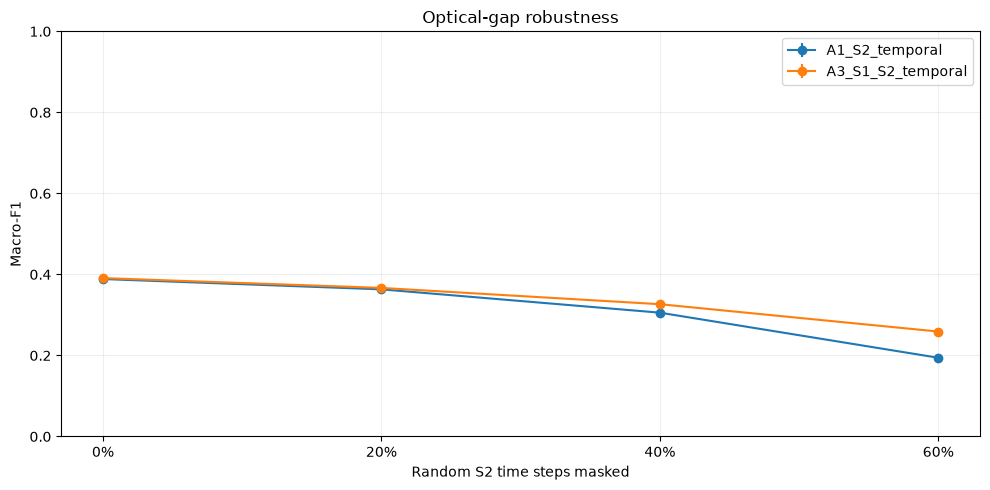

In [25]:
# ---------- FAST optical-gap robustness ----------
# Original implementation retrained a leader hundreds of times.
# Training data never changes between masking scenarios, so each leader is now
# fitted only ONCE per fold and reused for every test-time perturbation.

def build_period_column_map(columns):
    cols = list(columns)
    by_period = {}
    for p in EXPECTED_PERIODS:
        suffix=f'__p{p:02d}'
        by_period[p]=np.array([
            j for j,c in enumerate(cols)
            if c.endswith(suffix) and any(c.startswith(f+'__p') for f in S2_SIGNAL)
        ], dtype=int)
    return by_period

def mask_s2_test_fast(Xtest, by_period, fraction=None, contiguous_periods=None, seed=42):
    Z = Xtest.to_numpy(dtype=np.float32, copy=True)
    rng=np.random.default_rng(seed)

    for i in range(Z.shape[0]):
        if contiguous_periods is not None:
            n=int(contiguous_periods)
            start=int(rng.integers(0,len(EXPECTED_PERIODS)-n+1))
            periods=EXPECTED_PERIODS[start:start+n]
        else:
            n=(
                max(1,int(round(float(fraction)*len(EXPECTED_PERIODS))))
                if fraction is not None and fraction>0
                else 0
            )
            periods=(
                rng.choice(EXPECTED_PERIODS,size=n,replace=False).tolist()
                if n else []
            )

        if periods:
            idx=np.concatenate([by_period[p] for p in periods])
            if len(idx):
                Z[i,idx]=np.nan

    return pd.DataFrame(Z,index=Xtest.index,columns=Xtest.columns)

robust_rows=[]

if RUN_ROBUSTNESS:
    s2_rank=leaderboard[
        leaderboard['feature_set']=='A1_S2_temporal'
    ]
    fu_rank=leaderboard[
        leaderboard['feature_set']=='A3_S1_S2_temporal'
    ]

    configs=[
        ('random_0',0,None),
        ('random_20',0.2,None),
        ('random_40',0.4,None),
        ('random_60',0.6,None),
        ('contiguous_20d',None,2),
        ('contiguous_40d',None,4)
    ]

    for fs,rank in [
        ('A1_S2_temporal',s2_rank),
        ('A3_S1_S2_temporal',fu_rank)
    ]:
        if rank.empty:
            continue

        model_name=rank.iloc[0]['model']
        Xbase=FEATURE_SETS[fs].astype(np.float32)
        by_period=build_period_column_map(Xbase.columns)

        print('\nRobustness:',fs,'leader=',model_name)

        # Fit once per fold.
        fold_cache=[]

        for fold,(tr,te) in enumerate(folds):
            imputer, scaler, Xtr = fit_preprocessor(Xbase.iloc[tr])

            model=clone(MODELS[model_name])
            model.fit(Xtr,y[tr])

            fold_cache.append({
                'fold':fold,
                'tr':tr,
                'te':te,
                'imputer':imputer,
                'scaler':scaler,
                'model':model,
                'Xtest_raw':Xbase.iloc[te].copy(),
            })

        for cfg,fraction,contig in configs:
            repeats = 1 if cfg=='random_0' else P['robustness_repeats']

            for repeat in range(repeats):
                yt_all=[]
                yp_all=[]

                for C in fold_cache:
                    fold=C['fold']
                    te=C['te']

                    if cfg=='random_0':
                        Xmask=C['Xtest_raw']
                    else:
                        Xmask=mask_s2_test_fast(
                            C['Xtest_raw'],
                            by_period,
                            fraction=fraction,
                            contiguous_periods=contig,
                            seed=RANDOM_STATE + repeat*100 + fold
                        )

                    Xte=transform_preprocessor(
                        C['imputer'],
                        C['scaler'],
                        Xmask
                    )

                    pr=C['model'].predict(Xte)

                    yt_all.extend(y[te].tolist())
                    yp_all.extend(pr.tolist())

                robust_rows.append({
                    'feature_set':fs,
                    'model':model_name,
                    'scenario':cfg,
                    'repeat':repeat,
                    **metrics(np.array(yt_all),np.array(yp_all))
                })

        del fold_cache
        gc.collect()

robustness=pd.DataFrame(robust_rows)

if not robustness.empty:
    display(
        robustness.groupby(
            ['feature_set','scenario']
        )['macro_f1'].agg(['mean','std'])
    )

    robustness.to_csv(
        OUT/'optical_gap_robustness.csv',
        index=False
    )

    r=(
        robustness.groupby(
            ['feature_set','scenario']
        )['macro_f1']
        .agg(['mean','std'])
        .reset_index()
    )

    fig,ax=plt.subplots(figsize=(10,5))
    scenarios=[
        'random_0',
        'random_20',
        'random_40',
        'random_60'
    ]
    x=np.arange(len(scenarios))

    for fs,g in r[
        r['scenario'].isin(scenarios)
    ].groupby('feature_set'):
        g=g.set_index('scenario').reindex(scenarios)
        ax.errorbar(
            x,g['mean'],yerr=g['std'],
            marker='o',label=fs
        )

    ax.set_xticks(x)
    ax.set_xticklabels(['0%','20%','40%','60%'])
    ax.set_xlabel('Random S2 time steps masked')
    ax.set_ylabel('Macro-F1')
    ax.set_ylim(0,1)
    ax.set_title('Optical-gap robustness')
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.savefig(
        OUT/'07_optical_gap_robustness.png',
        dpi=180
    )
    plt.show()
else:
    print('Robustness experiment disabled or no leaders available.')


,period_index,fields,ndvi_valid_fraction,mean_s2_clear_frac,s1_any_fraction
0,0,5551,0.927941,0.853257,0.785624
1,1,5551,0.905963,0.452117,1.000000
2,2,5551,0.987210,0.847040,1.000000
3,3,5551,0.951360,0.827253,1.000000
4,4,5551,0.702576,0.570438,1.000000
5,5,5551,0.902360,0.594578,0.980184
6,6,5551,0.246983,0.219645,0.853360
7,7,5551,0.584940,0.339293,1.000000
8,8,5551,0.491983,0.455451,0.980184
9,9,5551,0.497568,0.429968,1.000000


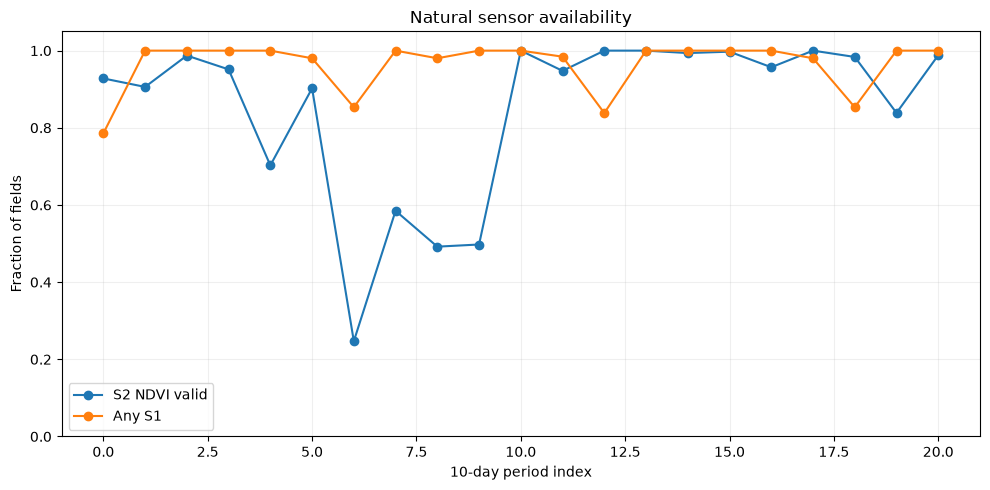

In [26]:
# ---------- Natural missingness / cloud-gap summary ----------
qa = long.groupby('period_index').agg(
    fields=('field_id','nunique'),
    ndvi_valid_fraction=('NDVI',lambda x:x.notna().mean()),
    mean_s2_clear_frac=('S2_CLEAR_FRAC','mean'),
    s1_any_fraction=('S1_TOTAL_COUNT',lambda x:(pd.to_numeric(x,errors='coerce').fillna(0)>0).mean())
).reset_index()
display(qa)
qa.to_csv(OUT/'period_sensor_coverage.csv',index=False)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(qa['period_index'],qa['ndvi_valid_fraction'],marker='o',label='S2 NDVI valid')
ax.plot(qa['period_index'],qa['s1_any_fraction'],marker='o',label='Any S1')
ax.set_ylim(0,1.05); ax.set_xlabel('10-day period index'); ax.set_ylabel('Fraction of fields'); ax.set_title('Natural sensor availability'); ax.grid(alpha=0.2); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'08_natural_sensor_coverage.png',dpi=180); plt.show()


## 8. Final paper checks

The notebook is intended to be used only after the following pass:

- all 8 periodic-feature batches present;
- all 8 observation-template batches present;
- 5,551 unique fields;
- 116,571 field-period rows;
- exactly 21 periods (0–20) for every field;
- no duplicate field-period rows;
- no crop-label conflicts;
- observation-template field IDs all belong to the periodic table;
- rare-class support is retained and reported;
- validation mode is stated exactly as run;
- crop results are described as crop classification, not phenology-ground-truth prediction.


In [27]:
# ---------- Final run manifest ----------
manifest={
    'execution_environment':'local_jupyter',
    'project_root':str(PROJECT_ROOT),
    'data_dir':str(DATA_DIR),
    'output_dir':str(OUT),
    'run_profile':RUN_PROFILE,
    'gpu_available':bool(GPU_AVAILABLE),
    'gpu_info':GPU_INFO,
    'cpu_threads':int(CPU_THREADS),
    'found_periodic_batches':sorted(int(x) for x in found_batches if x is not None),
    'found_observation_batches':sorted(int(x) for x in found_obs_batches if x is not None),
    'missing_periodic_batches':sorted(int(x) for x in missing_batches),
    'missing_observation_batches':sorted(int(x) for x in missing_obs_batches),
    'rows':int(len(long)),
    'unique_fields':int(long['field_id'].nunique()),
    'unique_periods':int(long['period_index'].nunique()),
    'classes':CLASS_NAMES,
    'validation_mode':VALIDATION_MODE,
    'n_folds':int(N_FOLDS),
    'paper_grade_complete_8_plus_8':bool(len(missing_batches)==0 and len(missing_obs_batches)==0),
    'paper_grade_spatial_validation':bool(VALIDATION_MODE.startswith('spatial')),
}
print(json.dumps(manifest,indent=2))
with open(OUT/'run_manifest.json','w') as f: json.dump(manifest,f,indent=2)

# Package all outputs.
zip_path=RESULTS_ZIP
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        if p.is_file(): z.write(p,arcname=p.name)
print('\nResults ZIP:',zip_path)
print('Results are saved locally; no browser download step is required.')


{
  "execution_environment": "local_jupyter",
  "project_root": "/mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet",
  "data_dir": "/mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/data",
  "output_dir": "/mnt/c/Users/admin/Saved Games/AgriSense/AgriFieldNet/agrifieldnet_final_outputs",
  "run_profile": "paper",
  "gpu_available": true,
  "gpu_info": "NVIDIA GeForce RTX 2050, 4096 MiB",
  "cpu_threads": 11,
  "found_periodic_batches": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7
  ],
  "found_observation_batches": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7
  ],
  "missing_periodic_batches": [],
  "missing_observation_batches": [],
  "rows": 116571,
  "unique_fields": 5551,
  "unique_periods": 21,
  "classes": [
    "Bersem",
    "Coriander",
    "Garlic",
    "Gram",
    "Green pea",
    "Lentil",
    "Maize",
    "Mustard",
    "No crop/Fallow",
    "Potato",
    "Rice",
    "Sugarcane",
    "Wheat"
  ],
  "validation_mode": "spatial_grid_stratified_